# Using Input Variables

## Input Variables

The **PyMCSimMod** package allows one to solve initial value problems for ordinary differential equation (ODE) models that include input variables. These are variables that may vary in time, but which are not state variables and which are independent of other model variables (including parameters). ODE solvers generally refer to these variables as "forcing functions" to describe such input variables. Each backend solver handles forcing functions in its own way and **PyMCSimMod** uses a general API to handle input variables for models solved with different backend solvers.

## A Classical Pharmacokinetic Model

For this demonstration, we will use the classical pharmacokinetic (PK) model illustrated in the figure below.

![Pharmacokinetic Model](pk1.png)

In this ODE model, there are three "compartments" (represented as rectangular boxes in the figure) for which amounts of substance are tracked as state variables: $A_0$ represents the amount of substance in the "exposure compartment" (e.g., the gut in an oral dosing scenario); $A_1$ represents the amount of substance in the "central compartment" (e.g., in the blood of the organism); and $A_2$ represents the amount that has been cleared from the body (e.g., via metabolism or excretion). Thus,

$$
\begin{align}
  \frac{\textrm{d}}{\textrm{d}t}A_0(t) &= -k_{01} A_0(t), \\
  \frac{\textrm{d}}{\textrm{d}t}A_1(t) &= k_{01} A_0(t) - k_{12} A_1(t), \textrm{ and} \\
  \frac{\textrm{d}}{\textrm{d}t}A_2(t) &= k_{12} A_1(t), \\
\end{align}
$$

where $k_{01}$ is the rate constant (with units of one over time) that, along with the value of $A_0$, determines the rate of delivery of the substance to the body and $k_{12}$ is the rate constant (with units of one over time) that, along with the value of $A_1$, determines the rate of clearance from the body. In addition to the state variables, the model includes an "output" variable, $C$, that represents the concentration in the central compartment. The value of this variable is computed as

$$
\begin{equation}
  C(t) = \frac{A_1(t)}{V_\textrm{d}(t)},
\end{equation}
$$

where $V_\textrm{d}(t)$ is a variable representing the effective volume of the central compartment, or the "volume of distribution," at time $t$. For this model,

$$
\begin{equation}
  V_\textrm{d}(t) = V_\textrm{d}^\textrm{C} \cdot M(t),
\end{equation}
$$

where $V_\textrm{d}^\textrm{C}$ is a scaling constant (parameter) and $M(t)$ is an input variable that represents body mass. The model also includes an output variable,

$$
\begin{equation}
  A_\textrm{tot}(t) = A_0(t) + A_1(t) + A_2(t),
\end{equation}
$$

that represents the total amount of substance in the system. Finally, the model includes an additional state variable that represents the area under the concentration vs. time curve (AUC), as this is a quantity that is often computed in pharmacokinetic analyses. The AUC for the period from time $0$ to time $t$ is given by $\textrm{AUC}(t) = \int_0^t C(\tau) \, \textrm{d}\tau$ and thus the state equation for this quantity is

$$
\begin{equation}
  \frac{\textrm{d}}{\textrm{d}t} \textrm{AUC}(t) = C(t).
\end{equation}
$$

In order to solve an initial value problem for the classical PK model, one needs to provide the values of the three parameters ($k_{01}$, $k_{12}$, and $V_\textrm{d}^\textrm{C}$), an input variable ($M$), and the initial values of the four state variables ($A_0$, $A_1$, $A_2$, and $\textrm{AUC}$).

## MCSim Model Specification

We used the [GNU MCSim](https://www.gnu.org/software/mcsim/) model specification language to implement the classical PK model. The complete MCSim model specification file for this model, `pk1_input.model`, can be found in the `extdata` subdirectory of the **PyMCSimMod** package installation directory.

The model specification file uses the text symbols `A0`, `A1`, `A2`, and `AUC` to represent the state variables $A_0$, $A_1$, $A_2$, and $\textrm{AUC}$, respectively, and the text symbols `k01`, `k12`, and `VdC` to represent the parameters $k_{01}$, $k_{12}$, and $V_\textrm{d}^\textrm{C}$, respectively. The text symbol `M_in` is used to represent the input variable $M$ and the text symbol `M` is used to represent an output variable that is equal to $M$ at all times. (Including this "output" variable in the model allows one to obtain values of $M$ at various times once a simulation has been performed.) The text symbols `C` and `Atot` represent the output variables $C$ and $A_\textrm{tot}$. In addition, the text symbols `A0_init`, `A1_init`, `A2_init`, and `AUC_init` represent parameters that can be used to set (via the `updateY0()` method of the `Model` class) the initial conditions of the state variables.

## Building the Model

First, we load the **PyMCSimMod** package as follows.

In [1]:
%load_ext autoreload
%autoreload 2

from pymcsimmod import create_model

Using the following commands, we create a model object (i.e., an instance of the `ScipyModel` or `JaxModel` class) using the model specification file `pk1_input.model` that is included in the **PyMCSimMod** package. For this example, we will build both backends to demonstrate that input variables can be used with either backend solver.

In [2]:
import importlib.resources
with importlib.resources.path('pymcsimmod.data', 'pk1_input.model') as filename:
    pk1_jax = create_model(filename, backend="jax")
    pk1_scipy = create_model(filename, backend="scipy")

## Scipy Backend

### Predicting the Blood Concentration of a Substance Following Oral Dosing

Suppose we want to predict the blood concentration of a substance during the 20-hour period following oral ingestion of 100 mg of the substance. Let's assume that the oral absorption rate constant ($k_{01}$) is 1.0 $h^{-1}$, the clearance rate constant ($k_{12}$) is 0.5 $h^{-1}$, and the volume of distribution scaling constant ($V_\textrm{d}^\textrm{C}$) is 0.1 L/kg. These are the default values of those model parameters given in the model specification file, and we can verify this with the following commands.

In [3]:
pk1_scipy.update_constants(A0_init=100.0)
print(pk1_scipy.parameters)
print(pk1_scipy.Y0)

{'Vdc': 0.1, 'k01': 1, 'k12': 0.5, 'MW': 150, 'A0_init': 100.0, 'A1_init': 0, 'A2_init': 0, 'AUC_init': 0, 'OralDose': 0, 'OralDur': 0.01}
{'A0': 100.0, 'A1': 0, 'A2': 0, 'AUC': 0}


Suppose the animal being dosed has a body mass of 0.25 kg initially (i.e., at the beginning of the simulation) and a body mass of 1.0 kg 20 hours later. (Admittedly, this is a large relative increase in body mass over a 20-hour period, but serves to illustrate the diluting effect of increasing body mass on concentration, as we shall see.) We can define a list of the body mass at various times. These values will be used for interpolation at the times needed by the integrator during the simulation. We can create an appropriate input variable matrix for our simulation (and examine it) using the following commands.

Forcing functions in **PyMCSimMod** are specified using the `assign_forcing_function()` method of the `Model` class. This method takes as its arguments the name of the input variable (as a string) and the forcing function method. If interpolated values are used for an input variable, simply define the `times` and `values` keyword arguments. Additional backend-specific forcing functions are defined in the *forcing* directory.

In [4]:
pk1_scipy.assign_forcing_function('M_in',
                                   times = [0, 20],
                                   values = [0.25, 1.0],
                                   interpolation_method='linear')


We can perform a simulation that provides results for the desired output times (i.e., $t = 0, 0.1, 0.2, \ldots, 20.0$) using the following commands.

In [5]:
import numpy as np

# Define output times for simulation.
times = np.arange(start = 0, stop = 20, step = 0.1)

# Run simulation.
results_scipy = pk1_scipy.run_model(times)
out_scipy = results_scipy.dataframe

<Axes: xlabel='Time', ylabel='Body Mass (kg)'>

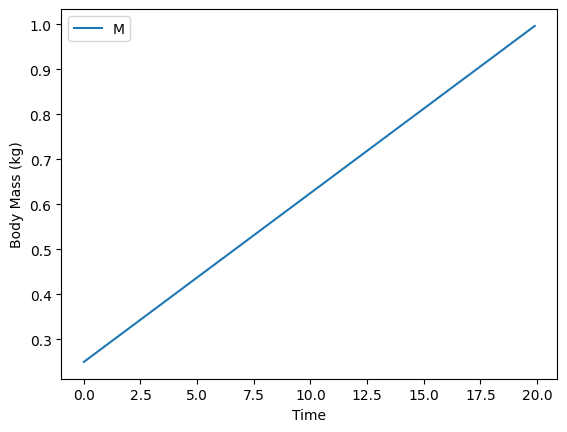

In [6]:
# Mass is interpolated from 0.25 to 1.0 over the 20 hours
results_scipy.plot_results(variables='M', ylabel='Body Mass (kg)')

We can perform a second simulation for which body mass remains constant at 0.25 kg using the following commands.

In [7]:
pk1_scipy.assign_forcing_function('M_in',
                                  'ConstFunc',
                                  value = 0.25)
# Run simulation.
results_scipy2 = pk1_scipy.run_model(times)
out_scipy2 = results_scipy2.dataframe

### Examining the Results

The results of the two simulations were stored in "matrix" data structures named `out_scipy` (for the time-varying body mass simulation) and `out_scipy2` (for the constant body mass simulation). In each matrix, there is one row for each output time, and one column for each state variable and each output variable. The first five rows of `out_scipy` are shown below. Note that the independent variable, which is $t$ in the case of the classical PK model, is always labeled "time" in the output data structure.

In [8]:
out_scipy.head()

,time,A0,A1,A2,AUC,C,Atot,C_mg,C_umol,M
0,0.0,100.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.25000
1,0.1,90.483761,9.278365,0.237874,18.843522,365.649841,100.000000,365.649841,0.002438,0.25375
2,0.2,81.873067,17.221350,0.905583,71.046333,668.790282,100.000000,668.790282,0.004459,0.25750
3,0.3,74.081712,23.978162,1.940125,150.782857,917.824390,100.000000,917.824390,0.006119,0.26125
4,0.4,67.031794,29.682545,3.285660,253.026070,1120.096039,99.999999,1120.096039,0.007467,0.26500


We can create a visual representation of the simulation results. For example, we can plot the concentration vs. time using the following commands.

Text(0, 0.5, 'Concentration (mg/L)')

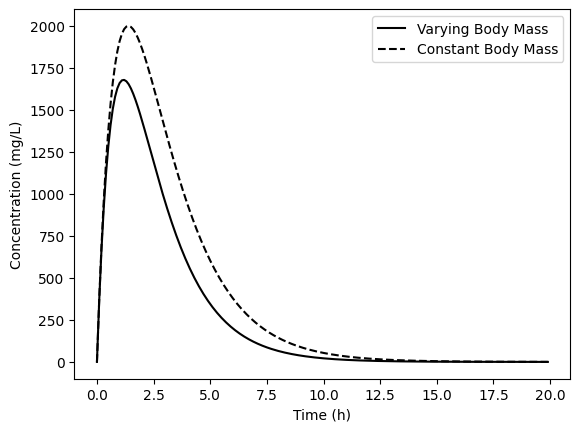

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(out_scipy['time'], out_scipy['C'], 'k-', label="Varying Body Mass")
ax.plot(out_scipy2['time'], out_scipy2['C'], 'k--', label="Constant Body Mass")
ax.legend(loc='best')
ax.set_xlabel('Time (h)')
ax.set_ylabel('Concentration (mg/L)')

## Jax Backend

### Predicting the Blood Concentration of a Substance Following Oral Dosing

Suppose we want to predict the blood concentration of a substance during the 20-hour period following oral ingestion of 100 mg of the substance. Let's assume that the oral absorption rate constant ($k_{01}$) is 1.0 $h^{-1}$, the clearance rate constant ($k_{12}$) is 0.5 $h^{-1}$, and the volume of distribution scaling constant ($V_\textrm{d}^\textrm{C}$) is 0.1 L/kg. These are the default values of those model parameters given in the model specification file, and we can verify this with the following commands.

In [10]:
pk1_jax.update_constants(A0_init=100.0)
print(pk1_jax.parameters)
print(pk1_jax.Y0)

{'Vdc': 0.1, 'k01': 1, 'k12': 0.5, 'MW': 150, 'A0_init': 100.0, 'A1_init': 0, 'A2_init': 0, 'AUC_init': 0, 'OralDose': 0, 'OralDur': 0.01}
{'A0': 100.0, 'A1': 0, 'A2': 0, 'AUC': 0}


Suppose the animal being dosed has a body mass of 0.25 kg initially (i.e., at the beginning of the simulation) and a body mass of 1.0 kg 20 hours later. (Admittedly, this is a large relative increase in body mass over a 20-hour period, but serves to illustrate the diluting effect of increasing body mass on concentration, as we shall see.) We can define a list of the body mass at various times. These values will be used for interpolation at the times needed by the integrator during the simulation. We can create an appropriate input variable matrix for our simulation (and examine it) using the following commands.

Forcing functions in **PyMCSimMod** are specified using the `assign_forcing_function()` method of the `Model` class. This method takes as its arguments the name of the input variable (as a string) and the forcing function method. If interpolated values are used for an input variable, simply define the `times` and `values` keyword arguments. Additional backend-specific forcing functions are defined in the *forcing* directory.

In [11]:
pk1_jax.assign_forcing_function('M_in',
                                times = [0, 20],
                                values = [0.25, 1.0],
                                interpolation_method='linear')


We can perform a simulation that provides results for the desired output times (i.e., $t = 0, 0.1, 0.2, \ldots, 20.0$) using the following commands.

In [12]:
import numpy as np

# Define output times for simulation.
times = np.arange(start = 0, stop = 20, step = 0.1)

# Run simulation.
results_jax = pk1_jax.run_model(times)
out_jax = results_jax.dataframe

We can perform a second simulation for which body mass remains constant at 0.25 kg using the following commands.

In [13]:
pk1_jax.assign_forcing_function('M_in',
                                  'ConstFunc',
                                  value = 0.25)
# Run simulation.
results_jax2 = pk1_jax.run_model(times)
out_jax2 = results_jax2.dataframe

### Examining the Results

The results of the two simulations were stored in "matrix" data structures named `out_jax` (for the time-varying body mass simulation) and `out_jax2` (for the constant body mass simulation). In each matrix, there is one row for each output time, and one column for each state variable and each output variable. The first five rows of `out_jax` are shown below demonstrating that the mass is increasing with time. Note that the independent variable, which is $t$ in the case of the classical PK model, is always labeled "time" in the output data structure.

In [14]:
out_jax.head()

,time,A0,A1,A2,AUC,C,Atot,C_mg,C_umol,M
0,0.0,100.000000,0.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.000000,0.25000
1,0.1,90.483772,9.278401,0.237857,18.841551,365.651306,100.000031,365.651306,0.002438,0.25375
2,0.2,81.873100,17.221346,0.905593,71.047897,668.790161,100.000038,668.790161,0.004459,0.25750
3,0.3,74.081841,23.977959,1.940228,150.796997,917.816650,100.000031,917.816650,0.006119,0.26125
4,0.4,67.032059,29.682142,3.285855,253.053345,1120.080811,100.000061,1120.080811,0.007467,0.26500


We can create a visual representation of the simulation results. For example, we can plot the concentration vs. time using the following commands.

Text(0, 0.5, 'Concentration (mg/L)')

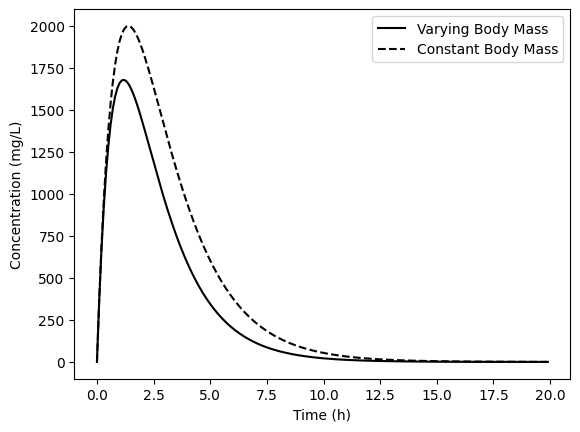

In [15]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(out_jax['time'], out_jax['C'], 'k-', label="Varying Body Mass")
ax.plot(out_jax2['time'], out_jax2['C'], 'k--', label="Constant Body Mass")
ax.legend(loc='best')
ax.set_xlabel('Time (h)')
ax.set_ylabel('Concentration (mg/L)')